In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold, ParameterGrid
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from transformers import AutoTokenizer, AutoModel
import torch.optim as optim
from tqdm import tqdm

In [2]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Load the data:

In [3]:
# Load the GearNet protein embeddings (structural-based)
protein_embs = torch.load("gearnet_embeddings.pt")
protein_embs = dict(sorted(protein_embs.items()))

In [4]:
# Generate the ligand embeddings
data = pd.read_csv('/dcs/22/u2243582/cs310/feature_extraction/refined-set-csv.csv')
codes = protein_embs.keys()
data = data[data['PDB_Code'].isin(codes)]
data = data.sort_values(by='PDB_Code')
ligand_SMILES = data['Ligand_SMILES'].tolist()
chemberta_model_name = "DeepChem/ChemBERTa-10M-MTR" # Load ligand embedding model (ChemBERTa)
chemberta_tokenizer = AutoTokenizer.from_pretrained(chemberta_model_name)
chemberta_model = AutoModel.from_pretrained(chemberta_model_name).to(device)

# Batch processing for ligand SMILES strings
def generate_ligand_embeddings(smiles_list, batch_size=4):
    chemberta_model.eval()
    all_embeddings = []
    
    with torch.no_grad():
        for i in tqdm(range(0, len(smiles_list), batch_size), desc="Processing Ligand Batches"):
            batch = smiles_list[i:i + batch_size]
            inputs = chemberta_tokenizer(batch, return_tensors="pt", padding=True, truncation=True).to(device)
            outputs = chemberta_model(**inputs)
            # Extract the last layer and apply mean pooling
            embeddings = outputs.last_hidden_state.mean(dim=1)
            all_embeddings.append(embeddings)
            # Clear GPU memory after processing the batch
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
    
    return torch.cat(all_embeddings, dim=0)

ligand_embeddings = generate_ligand_embeddings(ligand_SMILES)
print(f"Ligand embeddings shape: {ligand_embeddings.shape}") # (5057, 384)

2025-03-31 16:02:09.310554: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-31 16:02:09.391233: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-31 16:02:10.119177: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /local/java/cuda-11.6.0/lib64/:/local/java/cudnn-linux-x86_64-8.5.0.96_cuda11-archive/l

Ligand embeddings shape: torch.Size([5057, 384])


In [5]:
# Single array of embeddings data
protein_embeddings = torch.stack(list(protein_embs.values()))
protein_embeddings = protein_embeddings.squeeze(1) # (5057, 1536)

embeddings = torch.cat((protein_embeddings, ligand_embeddings), dim=1)
print(embeddings.shape) # (5057, 1920)

torch.Size([5057, 1920])


In [6]:
y = data['Log_binding'].to_numpy()
y = torch.tensor(y, dtype=torch.float32)

# Scale the data so one type of embedding (protein or ligand) doesn’t dominate the model due to larger magnitude values.
# embeddings_np = embeddings.cpu().numpy()
# scaler = StandardScaler()
# X = scaler.fit_transform(embeddings_np)
# X = torch.tensor(X, dtype=torch.float32, device=embeddings.device)
X = embeddings

# # PCA
# pca = PCA(0.85) # keep 80% of the variance of the data
# pca.fit(X)
# X = pca.transform(X)

# print ("Components:", pca.n_components_ , "Total explained variance:", pca.explained_variance_ratio_.sum())

In [7]:
print(type(embeddings),type(y),embeddings.shape,y.shape)

<class 'torch.Tensor'> <class 'torch.Tensor'> torch.Size([5057, 1920]) torch.Size([5057])


## Define the MLP model

In [8]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate, num_hidden_layers):
        super(MLP, self).__init__()
        
        self.hidden_layers = nn.ModuleList()

        # First hidden layer
        self.hidden_layers.append(nn.Linear(input_dim, hidden_dim))
        self.hidden_layers.append(nn.BatchNorm1d(hidden_dim))
        
        # Second hidden layer
        self.hidden_layers.append(nn.Linear(hidden_dim, hidden_dim))
        self.hidden_layers.append(nn.BatchNorm1d(hidden_dim))
        
        # Third hidden layer (if num_hidden_layers == 3)
        if num_hidden_layers == 3:
            self.hidden_layers.append(nn.Linear(hidden_dim, hidden_dim))
            self.hidden_layers.append(nn.BatchNorm1d(hidden_dim))
            
        # Third hidden layer (if num_hidden_layers == 4)
        if num_hidden_layers == 4:
            self.hidden_layers.append(nn.Linear(hidden_dim, hidden_dim))
            self.hidden_layers.append(nn.BatchNorm1d(hidden_dim))

        # Output layer
        self.output_layer = nn.Linear(hidden_dim, 1)

        # Dropout
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, x):
        for i in range(0, len(self.hidden_layers), 2):  # Skip BatchNorm
            x = self.hidden_layers[i](x)
            x = self.hidden_layers[i+1](x)  # BatchNorm
            x = torch.relu(x)
            if i < len(self.hidden_layers) - 2:  # Apply dropout only to hidden layers, NOT before output
                x = self.dropout(x)

        x = self.output_layer(x)  # No dropout before output
        return x

In [9]:
def train(model, train_loader, val_loader, criterion, optimizer, patience=10, epochs=50): # patience for early stopping over N epochs
    model.to(device)
    best_loss = float("inf")
    patience_counter = 0
    epoch_losses = []
    
    for epoch in range(epochs):
        model.train() 
        train_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad() 
            y_pred = model(X_batch).squeeze()
            loss = criterion(y_pred, y_batch.squeeze()) 
            loss.backward() 
            optimizer.step() 
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        epoch_losses.append(avg_train_loss)

        # ---- Validation Step ----
        model.eval() 
        val_loss = 0

        with torch.no_grad():
            for X_val_batch, y_val_batch in val_loader:
                X_val_batch, y_val_batch = X_val_batch.to(device), y_val_batch.to(device)
                y_val_pred = model(X_val_batch).squeeze()
                loss = criterion(y_val_pred, y_val_batch.squeeze())
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)

        # ---- Early Stopping Check ----
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                #print(f"Early stopping after {epoch+1} epochs")
                break

    return epoch_losses  

## Nested CV using MLP (5 outer 3 inner)

In [11]:
param_grid = {
    "hidden_dim": [512, 1024, 2048], 
    "dropout_rate": [0.0, 0.1, 0.2, 0.3],
    "learning_rate": [0.1, 0.01, 0.005, 0.001], 
    "num_hidden_layers": [2, 3, 4],
    "loss": [nn.MSELoss(), nn.L1Loss()],
    "weight-decay": [0, 1e-6, 1e-5, 1e-4]
}

# ---- Outer Loop ----
outer_kf = KFold(n_splits=5, shuffle=True, random_state=1)
all_loss_curves = []

results = [] # Store results

for fold, (train_idx, test_idx) in enumerate(outer_kf.split(X)):
    print(f"Outer Fold {fold+1}/5")
    
    random_params = [
    {key: random.choice(values) for key, values in param_grid.items()} 
    for _ in range(10)
    ]

    X_train_outer, X_test_outer = X[train_idx], X[test_idx]
    y_train_outer, y_test_outer = y[train_idx], y[test_idx]

    inner_kf = KFold(n_splits=3, shuffle=True, random_state=1)
    best_params = None
    best_val_loss = float("inf")
    
    # ---- Inner Loop: Hyperparameter Tuning ----
    for params in random_params:
        #print("Using hyperparams", params)
        
        val_losses = []

        for train_inner_idx, val_idx in inner_kf.split(X_train_outer):
            X_train_inner, X_val = X_train_outer[train_inner_idx], X_train_outer[val_idx]
            y_train_inner, y_val = y_train_outer[train_inner_idx], y_train_outer[val_idx]

            train_loader = DataLoader(TensorDataset(X_train_inner, y_train_inner), batch_size=32, shuffle=True)
            val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32, shuffle=False)

            model = MLP(input_dim=X_train_outer.shape[1], 
                hidden_dim=params["hidden_dim"], 
                dropout_rate=params["dropout_rate"], 
                num_hidden_layers=params["num_hidden_layers"]).to(device)
            criterion = params["loss"]
            optimizer = optim.Adam(model.parameters(), lr=params["learning_rate"], weight_decay=params["weight-decay"])

            epoch_losses = train(model, train_loader, val_loader, criterion, optimizer, epochs=50)
            val_losses.append(min(epoch_losses))

        mean_val_loss = np.mean(val_losses)

        if mean_val_loss < best_val_loss:
            best_val_loss = mean_val_loss
            best_params = params

    print(f"Best hyperparams for Fold {fold+1}: {best_params}")
    
    # ---- Train Final Model with Best Hyperparams ----
    train_loader = DataLoader(TensorDataset(X_train_outer, y_train_outer), batch_size=64, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test_outer, y_test_outer), batch_size=64, shuffle=False)

    model = MLP(input_dim=X_train_outer.shape[1], 
                hidden_dim=best_params["hidden_dim"], 
                dropout_rate=best_params["dropout_rate"], 
                num_hidden_layers=best_params["num_hidden_layers"]).to(device)
    criterion = best_params["loss"]
    optimizer = optim.Adam(model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight-decay"])

    epoch_losses = train(model, train_loader, test_loader, criterion, optimizer, epochs=50)
    all_loss_curves.append(epoch_losses)
    
    # ---- Evaluate Model ----
    model.eval()
    y_pred_list, y_true_list = [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_pred = model(X_batch).squeeze().cpu().numpy()
            y_true = y_batch.squeeze().cpu().numpy()

            y_pred_list.extend(y_pred)
            y_true_list.extend(y_true)

    pearson_corr, pearson_p = pearsonr(y_true_list, y_pred_list)
    spearman_corr, spearman_p = spearmanr(y_true_list, y_pred_list)
    mae = mean_absolute_error(y_true_list, y_pred_list)
    variance = np.var(np.array(y_true_list) - np.array(y_pred_list))
    r2 = r2_score(y_true_list, y_pred_list)

    results.append({"Fold": fold+1, "Pearson": pearson_corr, "Pearson p": pearson_p, "Spearman": spearman_corr, "Spearman p": spearman_p, "MAE": mae, "Variance": variance, "R2": r2})

Outer Fold 1/5
Best hyperparams for Fold 1: {'hidden_dim': 2048, 'dropout_rate': 0.3, 'learning_rate': 0.005, 'num_hidden_layers': 4, 'loss': L1Loss(), 'weight-decay': 1e-06}
Outer Fold 2/5
Best hyperparams for Fold 2: {'hidden_dim': 1024, 'dropout_rate': 0.0, 'learning_rate': 0.005, 'num_hidden_layers': 4, 'loss': L1Loss(), 'weight-decay': 0}
Outer Fold 3/5
Best hyperparams for Fold 3: {'hidden_dim': 2048, 'dropout_rate': 0.0, 'learning_rate': 0.001, 'num_hidden_layers': 4, 'loss': L1Loss(), 'weight-decay': 1e-06}
Outer Fold 4/5
Best hyperparams for Fold 4: {'hidden_dim': 2048, 'dropout_rate': 0.0, 'learning_rate': 0.01, 'num_hidden_layers': 4, 'loss': L1Loss(), 'weight-decay': 1e-06}
Outer Fold 5/5
Best hyperparams for Fold 5: {'hidden_dim': 1024, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'num_hidden_layers': 3, 'loss': L1Loss(), 'weight-decay': 1e-06}


In [12]:
print(results)

[{'Fold': 1, 'Pearson': 0.6894602330867204, 'Pearson p': 1.237697388471466e-143, 'Spearman': 0.6714564351266553, 'Spearman p': 1.3019263355359856e-133, 'MAE': 1.0892441, 'Variance': 1.9615184, 'R2': 0.46483212377341165}, {'Fold': 2, 'Pearson': 0.6986304667268145, 'Pearson p': 5.012958673158412e-149, 'Spearman': 0.6872032369600498, 'Spearman p': 2.4495240149415847e-142, 'MAE': 1.1391447, 'Variance': 1.9844763, 'R2': 0.4457942185411786}, {'Fold': 3, 'Pearson': 0.6643746845556653, 'Pearson p': 9.813283560873919e-130, 'Spearman': 0.6600799060944258, 'Spearman p': 1.638428373224858e-127, 'MAE': 1.1592774, 'Variance': 2.2899816, 'R2': 0.4018584429076465}, {'Fold': 4, 'Pearson': 0.6991042116774822, 'Pearson p': 3.6460445908978862e-149, 'Spearman': 0.6897332231004226, 'Spearman p': 1.1896868452220185e-143, 'MAE': 1.1079208, 'Variance': 1.9979414, 'R2': 0.481373478041052}, {'Fold': 5, 'Pearson': 0.7248909269448975, 'Pearson p': 1.6432449331916153e-165, 'Spearman': 0.7217015856153625, 'Spearman 

In [13]:
# Nested CV Extract metrics
pearson_scores = [result['Pearson'] for result in results]
spearman_scores = [result['Spearman'] for result in results]
mae_scores = [result['MAE'] for result in results]
var_scores = [result['Variance'] for result in results]
r2_scores = [result['R2'] for result in results]
pearson_p_values = [result['Pearson p'] for result in results]
spearman_p_values = [result['Spearman p'] for result in results]

# Calculate means and standard deviations
pearson_mean = np.mean(pearson_scores)
pearson_std = np.std(pearson_scores)

spearman_mean = np.mean(spearman_scores)
spearman_std = np.std(spearman_scores)

mae_mean = np.mean(mae_scores)
mae_std = np.std(mae_scores)

var_mean = np.mean(var_scores)
var_std = np.std(var_scores)

r2_mean = np.mean(r2_scores)
r2_std = np.std(r2_scores)

pearson_p_mean = np.mean(pearson_p_values)
pearson_p_std = np.std(pearson_p_values)

spearman_p_mean = np.mean(spearman_p_values)
spearman_p_std = np.std(spearman_p_values)

# Print the results
print(f"Pearson Correlation: Mean = {pearson_mean}, Std = {pearson_std}, p-value Mean = {pearson_p_mean}, p-value Std = {pearson_p_std}")
print(f"Spearman Correlation: Mean = {spearman_mean}, Std = {spearman_std}, p-value Mean = {spearman_p_mean}, p-value Std = {spearman_p_std}")
print(f"MAE: Mean = {mae_mean}, Std = {mae_std}")
print(f"Variance: Mean = {var_mean}, Std = {var_std}")
print(f"R2: Mean = {r2_mean}, Std = {r2_std}")

Pearson Correlation: Mean = 0.6952921045983159, Std = 0.01945078247171551, p-value Mean = 1.9626567121748085e-130, p-value Std = 3.925313424349555e-130
Spearman Correlation: Mean = 0.6860348773793832, Std = 0.020848733364363513, p-value Mean = 3.2768593503023924e-128, p-value Std = 6.553712190975034e-128
MAE: Mean = 1.11044442653656, Std = 0.036220405250787735
Variance: Mean = 2.030364513397217, Std = 0.13262340426445007
R2: Mean = 0.4569314700303762, Std = 0.03150848851979662


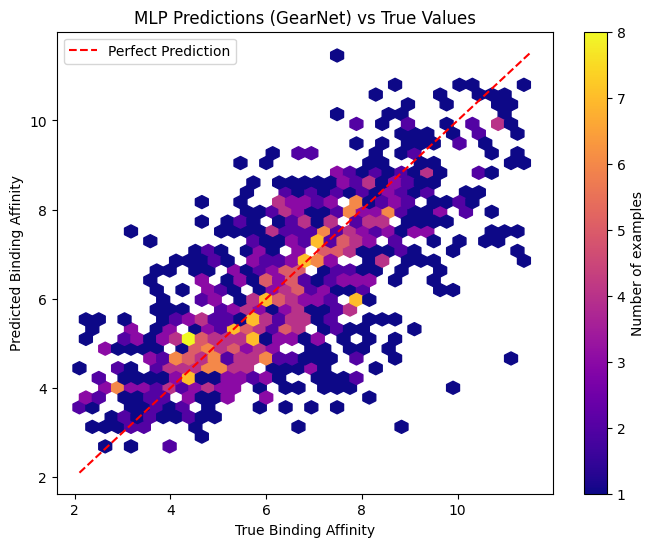

In [14]:
# Create hexbin plot
plt.figure(figsize=(8, 6))
hb = plt.hexbin(y_true_list, y_pred_list, gridsize=35, cmap='plasma', mincnt=1)

# Add a colorbar to indicate density
cb = plt.colorbar(hb)
cb.set_label('Number of examples')

# Add labels and title
plt.xlabel("True Binding Affinity")
plt.ylabel("Predicted Binding Affinity")
plt.title("MLP Predictions (GearNet) vs True Values")

# Add a diagonal line y = x to show the ideal prediction
min_val = min(min(y_true_list), min(y_pred_list))
max_val = max(max(y_true_list), max(y_pred_list))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

# Add legend
plt.legend()

# Show the plot
plt.show()

## Nested CV using SVR

In [15]:
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV

cv_outer = KFold(n_splits=5, shuffle=True, random_state=1)

# Store metrics across folds
pearsonCoeffs = []
pearsonPValues = []
spearmanCoeffs = []
spearmanPValues = []
maeScores = []
varianceScores = []
r2Scores = []

# Move tensors to CPU and convert to NumPy
X_np = X.cpu().numpy()
y_np = y.cpu().numpy()

for train_ix, test_ix in cv_outer.split(X_np): # outer CV

    X_train, X_test = X_np[train_ix, :], X_np[test_ix, :]
    y_train, y_test = y_np[train_ix], y_np[test_ix]

    cv_inner = KFold(n_splits=3, shuffle=True, random_state=1)

    model = SVR()

    space = {
    "C": np.arange(2, 10, 2),
    "gamma": [0.1, 0.3, 0.5, 0.7, 0.9, 'scale', 'auto'],
    'epsilon': np.arange(0.1, 1, 0.1),
    'kernel': ['rbf']
    }
    
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=space,
        n_iter=25,
        cv=cv_inner, # nested CV
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )

    result = search.fit(X_train, y_train) # inner CV

    best_model = result.best_estimator_ # best hyperparams from inner 3-fold CV, test on outer test subset
    
    print(result.best_params_)

    yPred = best_model.predict(X_test)

    # Pearson Correlation
    pearsonCoef, pearsonP = pearsonr(y_test, yPred)
    pearsonCoeffs.append(pearsonCoef)
    pearsonPValues.append(pearsonP)
    
    # Spearman Correlation
    spearmanCoef, spearmanP = spearmanr(y_test, yPred)
    spearmanCoeffs.append(spearmanCoef)
    spearmanPValues.append(spearmanP)
    
    # Mean Absolute Error
    mae = mean_absolute_error(y_test, yPred)
    maeScores.append(mae)
    
    # Variance of Errors
    variance = np.var(y_test - yPred)
    varianceScores.append(variance)

    # R2 (Coefficient of Determination)
    r2 = r2_score(y_test, yPred)
    r2Scores.append(r2)
    
# Calculate mean and standard deviation for each metric
metricsSummary = {
    "Pearson Correlation": (np.mean(pearsonCoeffs), np.std(pearsonCoeffs)),
    "Pearson P-value": (np.mean(pearsonPValues), np.std(pearsonPValues)),
    "Spearman Correlation": (np.mean(spearmanCoeffs), np.std(spearmanCoeffs)),
    "Spearman P-value": (np.mean(spearmanPValues), np.std(spearmanPValues)),
    "Mean Absolute Error": (np.mean(maeScores), np.std(maeScores)),
    "Variance of Errors": (np.mean(varianceScores), np.std(varianceScores)),
    "R2": (np.mean(r2Scores), np.std(r2Scores))
}

# Print metrics summary
for metric, (mean, std) in metricsSummary.items():
    print(f"{metric}: Mean = {mean}, Std = {std}")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

{'kernel': 'rbf', 'gamma': 'scale', 'epsilon': 0.5, 'C': 4}
{'kernel': 'rbf', 'gamma': 'scale', 'epsilon': 0.30000000000000004, 'C': 4}
{'kernel': 'rbf', 'gamma': 0.1, 'epsilon': 0.2, 'C': 4}
{'kernel': 'rbf', 'gamma': 'scale', 'epsilon': 0.4, 'C': 8}
{'kernel': 'rbf', 'gamma': 'scale', 'epsilon': 0.30000000000000004, 'C': 6}
Pearson Correlation: Mean = 0.7092550792121383, Std = 0.018297899014575566
Pearson P-value: Mean = 1.2415075560618662e-135, Std = 2.4830151121237323e-135
Spearman Correlation: Mean = 0.7004899900861299, Std = 0.019245299966135117
Spearman P-value: Mean = 1.5842682720700253e-131, Std = 3.1685365441400506e-131
Mean Absolute Error: Mean = 1.0653535616821925, Std = 0.02980768876681852
Variance of Errors: Mean = 1.8945362064107623, Std = 0.10268619215100326
R2: Mean = 0.5008015504714299, Std = 0.02569888675780334


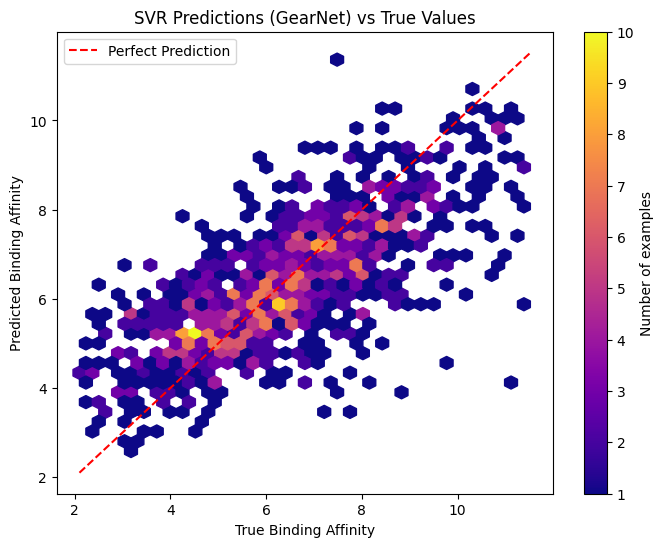

In [16]:
# Create hexbin plot
plt.figure(figsize=(8, 6))
hb = plt.hexbin(y_test, yPred, gridsize=35, cmap='plasma', mincnt=1)

# Add a colorbar to indicate density
cb = plt.colorbar(hb)
cb.set_label('Number of examples')

# Add labels and title
plt.xlabel("True Binding Affinity")
plt.ylabel("Predicted Binding Affinity")
plt.title("SVR Predictions (GearNet) vs True Values")

# Add a diagonal line y = x to show the ideal prediction
min_val = min(min(y_test), min(yPred))
max_val = max(max(y_test), max(yPred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

# Add legend
plt.legend()

# Show the plot
plt.show()